# Implementing a Directed Message Passing Neural Network from scratch

This notebook will walk through the theory implementation of the D-MPNN introduced by "Analyzing Learned Molecular Representations for Property Prediction" Yang et al. 2019.

The DMPNN is a variant of the classic message passing neural network, where the fundamental unit of representation is the directed bond states. This was specifically designed to overcome the tottering problem, where a message from node u to vb
 

We will first implement from scratch in pytorch, before moving to pytorch geometric. 

THe plan:

1. Build a toy graph
2. Get the DMPNN working on the toy graph
3. 

What is the input of our model?

For simplicity, let's imagine we're dealing with a molceular graph.

We represent a molecule as an (2-dimensional for now) undirected graph $G = (V, E)$, where $V = \{v_1, \dots, v_N\}$ is the set of $N$ nodes (atoms) and $E \subseteq V \times V$ is the set of edges (chemical bonds). The structure is encoded by the adjacency matrix $\mathbf{A} \in \{0, 1\}^{N \times N}$. Associated with each node $v_i$ is a feature vector $\mathbf{x}_i \in \mathbb{R}^F$ (e.g., atomic number, hybridization), forming a node feature matrix $\mathbf{X} \in \mathbb{R}^{N \times F}$. Similarly, each edge $(i,j) \in E$ is associated with a bond feature vector $\mathbf{b}_{ij} \in \mathbb{R}^D$ (e.g., bond type or order), forming a bond feature tensor $\mathbf{B} \in \mathbb{R}^{N \times N \times D}$, where $\mathbf{B}_{ij\cdot} = \mathbf{b}_{ij}$ when $(i,j) \in E$ and is zero otherwise. The complete attributed graph is thus represented as $G = (\mathbf{A}, \mathbf{X}, \mathbf{B})$.

In practice, it's much simpler to have $\mathbf{B}\in\mathbb{R}^{E \times D}$, where the rows of this bond feature matrix are indexed by the corresponding edge. For a directed graph, this would become $\mathbf{B}\in\mathbb{R}^{2E \times D}$, where each directed edge corresponds to a row. This way edge u->v can have a different feature vector than v->u. b

In chemprop, the default atom features are atom type, number of bonds, formal charge, etc. . The categorical features are one-hot ecoded, giving a 133 dimensional defult feature vector for each atom. For bonds we have bond type, conjugation, ring membership, stereo. Giving a 14 dimensional feature default vector for each bond. These features are readily available in RDKit. So in our setup, if we imagine a 5-atom molecule as follows, we have $N=5$, $E=5$, $F=144$, $D=14$

So how does the directed message passing neural network work? A standard MPNN takes the input graph and has T message passing steps. Each node gets initialized with a latent representation $h_{v}$. For each message passing step, we first compute the "message" from each node. A standard choice of "message" is simply the mean of the latent representation. Once we have the message from each node, we need to AGGREGATE the incoming m

In [1]:
#build a toy graph
import torch
torch.manual_seed(42)

N = 5
E = 5
F = 4 #144
D = 3 #14
d=6
c=F+D

A=torch.tensor([[0,1,0,1,0],
               [1,0,1,0,0],
               [0,1,0,1,0],
               [1,0,1,0,1],
               [0,0,0,1,0]]
               )

#lets get the edge list from here
edge_index = A.nonzero(as_tuple=False).T 
#edges is a 2x2E tensor, where each column represents the index of a non-zero element in A.
#  Row 1=row index, Row 2=col index

#now we need a bond feature matrix (we will generate this randomly for now),
#  where the size of the matrix comes from the edge list
# B=torch.rand(edge_index.shape[1], D)
#construct a random atom and bond feature matrix
# X=torch.rand(N, F)

X = torch.arange(N).unsqueeze(1).expand(N, F)
B = torch.arange(2*E).unsqueeze(1).expand(2*E, D)


X.shape, B.shape, edge_index.shape

(torch.Size([5, 4]), torch.Size([10, 3]), torch.Size([2, 10]))

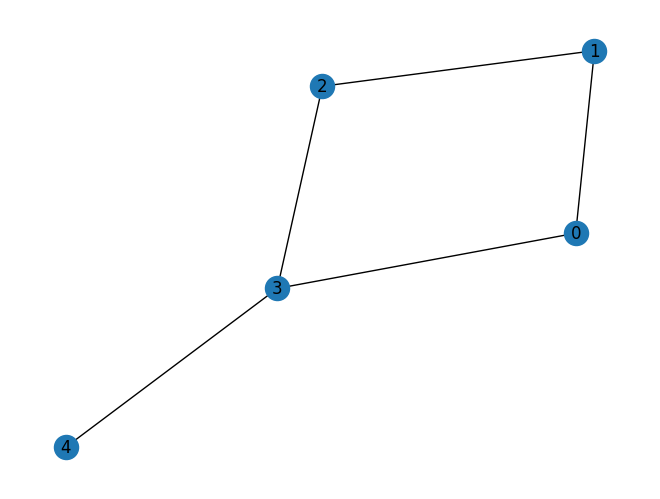

In [2]:
import networkx as nx
#draw network based on A
G = nx.from_numpy_array(A.numpy())
nx.draw(G, with_labels=True)


In [3]:
#so now we have our X, B, and edge list for indexing. For the DMPNN, we are going to need the reverse edge mapping
# for each directed edge i = (u->v), what edge index corresponds to (v->u)? why we need this will be clear later
src, rcv = edge_index

#first we'll make an edge index dict. we zip the two tensors, then enumerate, to create an iterator
#that contains an index, and the tuple of the matching dimension pairs from the two tensors
edge_dict = {(u.item(), v.item()): i for i, (u,v) in enumerate(zip(src, rcv))}


#interate over the zipped tensors, and assign the value (index) of the reverse edge
rev_index = torch.tensor([
edge_dict[(v.item(), u.item())] for u,v in zip(src,rcv)
])
#so now for each colum of edge index, the corresponding entry in rev_index points to the column of the reverse edge

In the DMPNN, we initialize the hidden states with the following:

$$
h_{vu}^{(0)} = \sigma\!\left(W_i [x_v \| b_{vu}]\right)
$$

where:

- $h_{vu}^{(0)}$ is the latent representation of the directed bond from node $v$ to $u$
- $x_v$ is the feature vector of the source node $v$
- $b_{vu}$ is the feature vector of the directed bond
- $W_i \in \mathbb{R}^{d \times c}$, is a learned initializing weight matrix to project representations into $\mathbb{R}^{d}$, where $d$ is the hidden dimension and $c$ is the dimension of the concatenated atom and bond feature vector

In [4]:
#before we can initialize by doing this concatenation, we have B = [10,D], but X = [5,F]
#we need to get the atom feature vector for each source node of each directed edge (expand X to 10xF)
src=edge_index[0]
X_src = X[src] #[10,F]

#start by concatenating bond feat vectors to atom feat vectors
C = torch.cat([X_src,B], dim=1).float()
C.shape #[2E, D+F]

torch.Size([10, 7])

In [5]:
C

tensor([[0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 1., 1., 1.],
        [1., 1., 1., 1., 2., 2., 2.],
        [1., 1., 1., 1., 3., 3., 3.],
        [2., 2., 2., 2., 4., 4., 4.],
        [2., 2., 2., 2., 5., 5., 5.],
        [3., 3., 3., 3., 6., 6., 6.],
        [3., 3., 3., 3., 7., 7., 7.],
        [3., 3., 3., 3., 8., 8., 8.],
        [4., 4., 4., 4., 9., 9., 9.]])

To compute all of the initial hidden states at one time, we can do the following:
$$
H^{(0)} = \sigma\!\left(CW_i^T\right)
$$

Where $H^{(0)}\in\mathbb{R}^{2E \times d}$ now contains the directed bond states. 

In [6]:
#initialize weight matrix via Glorot initilization
W_i = torch.empty(d,c)
W_i = torch.nn.init.xavier_uniform_(W_i)
# W_i = torch.ones(d,c) #temporarily for easier tracking
W_i_T = W_i.T

In [7]:
W_i_T

tensor([[ 0.5194,  0.3990,  0.3276, -0.0797,  0.0641,  0.4198],
        [ 0.5639,  0.5989, -0.0959, -0.2759, -0.6710,  0.1059],
        [-0.1592, -0.4984,  0.5237,  0.4507,  0.6135,  0.5489],
        [ 0.6241,  0.5905,  0.1004, -0.5363, -0.5771,  0.0743],
        [-0.1489,  0.1271, -0.3172, -0.3132,  0.5245, -0.2143],
        [ 0.1371,  0.5019,  0.1732, -0.1918,  0.1131,  0.1825],
        [-0.3308,  0.0920, -0.3130, -0.4085, -0.2206, -0.1842]])

In [8]:
# H_0 = torch.relu(torch.matmul(C,W_i_T))
H_0 = torch.matmul(C,W_i_T) #ignore relu for now
H_0.shape

torch.Size([10, 6])

The messages in the DMPNN are comuted by:
$$
m_{vu}^{(t+1)}=\sum_{k \in N(v) \backslash{u}}h_{kv}^{(t)}
$$

In words, the message of a directed bond from $v$ to $u$, is the sum of all latent bond representations of incoming bonds to $v$ EXCLUDING from node $u$. This is the critical distinction of the DMPNN, this exclusion avoids immediate message back passing. 

So to compute the matrix of messages $M$, for for each directed bond, we need to sum all of the incoming bond states, then subtract the bond states of recieving node of that bond. 

In [9]:
edge_index

tensor([[0, 0, 1, 1, 2, 2, 3, 3, 3, 4],
        [1, 3, 0, 2, 1, 3, 0, 2, 4, 3]])

In [10]:
#for each column in edge_index, the corresponding entry in rev_indxe points
#to the column of edge_index that is the reverse
rev_index

tensor([2, 6, 0, 4, 3, 7, 1, 5, 9, 8])

In [11]:
H_0

tensor([[ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000],
        [-0.3425,  0.7211, -0.4570, -0.9135,  0.4170, -0.2159],
        [ 0.8632,  2.5321, -0.0582, -2.2682,  0.2635,  0.7170],
        [ 0.5207,  3.2532, -0.5152, -3.1817,  0.6804,  0.5010],
        [ 1.7263,  5.0643, -0.1164, -4.5365,  0.5270,  1.4339],
        [ 1.3838,  5.7853, -0.5734, -5.4500,  0.9439,  1.2180],
        [ 2.5895,  7.5964, -0.1746, -6.8047,  0.7904,  2.1509],
        [ 2.2470,  8.3175, -0.6316, -7.7182,  1.2074,  1.9349],
        [ 1.9045,  9.0385, -1.0886, -8.6317,  1.6243,  1.7190],
        [ 3.1102, 10.8496, -0.6898, -9.9864,  1.4709,  2.6519]])

In [12]:
src

tensor([0, 0, 1, 1, 2, 2, 3, 3, 3, 4])

In [13]:
rcv

tensor([1, 3, 0, 2, 1, 3, 0, 2, 4, 3])

In [14]:
# #now we compute the "messages", starting with a single bond state
# # for a bond 0,1 get the indices of all bonds going to into 0
# #brute force loop
# M_1=torch.empty(2*E,d)
# #loop over directed edges
# for i in range(2*E):
#     v=src[i]
#     u=rcv[i]
#     m_vu = (rcv==v).nonzero(as_tuple=True)[0] #get indices of edges going into v
#     incoming_states = H_0[m_vu]
#     incoming_sum = incoming_states.sum(dim=0)

#     #get the reverse hidden state
#     reverse_state_index = rev_index[i] 
#     reverse_state = H_0[reverse_state_index]
#     m_vu = incoming_sum - reverse_state

#     #update message tensor
#     M_1[i]=m_vu

Now we need to update the states. The DMPNN uses the following update for a single hidden state:

\begin{equation}
    \mathbf{h}_{vu}^{(t+1)} = 
    \sigma\left(
        \mathbf{h}_{vu}^{(0)} + 
        \mathbf{W}_h \mathbf{m}_{vu}^{(t+1)}
    \right)
\end{equation}

so in matrix form:
$$H^{(1)}=\sigma\left(H^{(0)} + M^{(t+1)}W_h^T\right)$$


In [15]:
# # W_h = torch.empty(d,d)
# # W_h = torch.nn.init.xavier_uniform_(W_h)
# W_h = torch.eye(d,d)

# # H_1 = torch.relu(H_0 + torch.matmul(M_1,W_h.T))
# H_1 = H_0 + torch.matmul(M_1,W_h.T)
                        

In [17]:
def compute_messages(H):
    #brute force loop
    M=torch.empty(2*E,d)
    #loop over directed edges
    for i in range(2*E):
        v=src[i]
        u=rcv[i]
        m_vu = (rcv==v).nonzero(as_tuple=True)[0] #get indices of edges going into v
        incoming_states = H[m_vu]
        incoming_sum = incoming_states.sum(dim=0)

        #get the reverse hidden state
        reverse_state_index = rev_index[i] 
        reverse_state = H[reverse_state_index]
        m_vu = incoming_sum - reverse_state

        #update message tensor
        M[i]=m_vu
    return M

def update(H_0,M):
    W_h = torch.empty(d,d)
    W_h = torch.nn.init.xavier_uniform_(W_h)
    # W_h = torch.eye(d,d)

    H = torch.relu(H_0 + torch.matmul(M,W_h.T))
    # H = H_0 + torch.matmul(M,W_h.T)
    return H  

T=3
H=H_0
for t in range(T):
    M = compute_messages(H)
    H = update(H_0,M) #skip connection, not residual connection


Now, before the pooling step, we need to aggregate back to node-level representations. The DMPNN does this by summing all of the incoming hidden states:
$$
\begin{equation}
    \mathbf{h}_u = 
    \sum_{v \in \mathcal{N}(u)} 
    \mathbf{h}_{vu}^{(T)}
\end{equation}
$$
Then from there, to produce a single vector for the FFN to act on, we pool using the summation over all nodes

In [ ]:
R=torch.empty(N,d)
for v in range(N):
    m_vu = (rcv==v).nonzero(as_tuple=True)[0] #get indices of edges going into v
    incoming_states = H[m_vu]
    incoming_sum = incoming_states.sum(dim=0)
    #update message tensor
    R[v]=incoming_sum

z_G = torch.sum(R,dim=0)

tensor([[ 0.6538, 18.8492,  0.0000,  0.0000,  0.0000, 13.1478],
        [ 0.0000,  7.0144,  1.3393,  0.0000,  0.0000,  5.1994],
        [ 0.2198, 17.5822,  0.0279,  0.0000,  0.1706,  9.2684],
        [ 3.1102, 18.6252,  1.0083,  0.0000,  1.8984,  5.4188],
        [ 0.2279, 11.1437,  0.0000,  0.0000,  0.0000,  4.4732]])

In [42]:
import torch.nn as nn
class MLP(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()

        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size,hidden_size)
        self.fc3 = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.fc3(x)
        return x
    
f=100
ffn = MLP(d,f,1) #intantiate model

ffn(z_G.unsqueeze(0))



tensor([[1.9352]], grad_fn=<AddmmBackward0>)